# Week 3: Machine Learning Model Development & Performance Evaluation

## Customer Churn Prediction

**Programme:** Machine Learning Internship Programme  
**Organization:** AnalystLab Africa  
**Week:** Week 3  
**Project:** Customer Churn Prediction  

### Project Overview

Following the data understanding, exploratory data analysis, preprocessing, and feature engineering completed in Weeks 1 and 2, this project focuses on developing and evaluating supervised machine learning models for customer churn prediction.

The objective is to train multiple classification algorithms, compare their performance using standard evaluation metrics, identify important predictors of customer churn, and recommend the most suitable model for potential deployment.

### Business Objective

The business objective is to develop a machine learning solution capable of identifying customers who are likely to churn, allowing the telecommunications company to take proactive customer retention actions.

### Target Variable

The target variable is:

`Churn`

where:

- `0` = Customer does not churn
- `1` = Customer churns

### Models

The following classification algorithms will be evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

### Evaluation Metrics

Each model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

## 1. Import Required Libraries

The following libraries are used for data manipulation, visualization, preprocessing, machine learning model development, and model evaluation.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/kaggle/input/datasets/christianagyapong1/dataset/X_test_processed.csv
/kaggle/input/datasets/christianagyapong1/dataset/X_train_processed.csv


In [3]:
# Load Week 2 processed datasets

train_path = "/kaggle/input/datasets/christianagyapong1/dataset/X_train_processed.csv"
test_path = "/kaggle/input/datasets/christianagyapong1/dataset/X_test_processed.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)

Training dataset shape: (5634, 51)
Testing dataset shape: (1409, 51)


In [4]:
print("Training missing values:", train_df.isnull().sum().sum())
print("Testing missing values:", test_df.isnull().sum().sum())

Training missing values: 0
Testing missing values: 0


In [5]:
# Separate input features from target variable

target_column = "Churn"

X_train = train_df.drop(columns=[target_column])
y_train = train_df[target_column]

X_test = test_df.drop(columns=[target_column])
y_test = test_df[target_column]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 50)
y_train shape: (5634,)
X_test shape: (1409, 50)
y_test shape: (1409,)


In [6]:
print("Training Churn distribution:")
print(y_train.value_counts())

print("\nTesting Churn distribution:")
print(y_test.value_counts())

Training Churn distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Testing Churn distribution:
Churn
0    1035
1     374
Name: count, dtype: int64


## 5. Model Development

### 5.1 Logistic Regression

Logistic Regression is used as the first baseline classification model.

It is appropriate for binary classification because the target variable contains two classes:

- 0 = No Churn
- 1 = Churn

The model provides a useful baseline against which the other classification algorithms can be compared.

In [7]:
# Initialize Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [8]:
# Generate predictions

y_pred_logistic = logistic_model.predict(X_test)

# Generate probability predictions for ROC-AUC
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [9]:
# Calculate evaluation metrics

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)
logistic_roc_auc = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression Performance")
print("=" * 40)
print(f"Accuracy:  {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"F1 Score:  {logistic_f1:.4f}")
print(f"ROC-AUC:   {logistic_roc_auc:.4f}")

Logistic Regression Performance
Accuracy:  0.7991
Precision: 0.6532
Recall:    0.5187
F1 Score:  0.5782
ROC-AUC:   0.8424


In [10]:
print("Logistic Regression Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["No Churn", "Churn"]
    )
)

Logistic Regression Classification Report
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



### Confusion Matrix

The confusion matrix shows how correctly the Logistic Regression model classified customers into the two churn categories.

It helps identify:

- True Negatives
- False Positives
- False Negatives
- True Positives

False negatives are particularly important in churn prediction because they represent customers who actually churned but were not identified by the model.

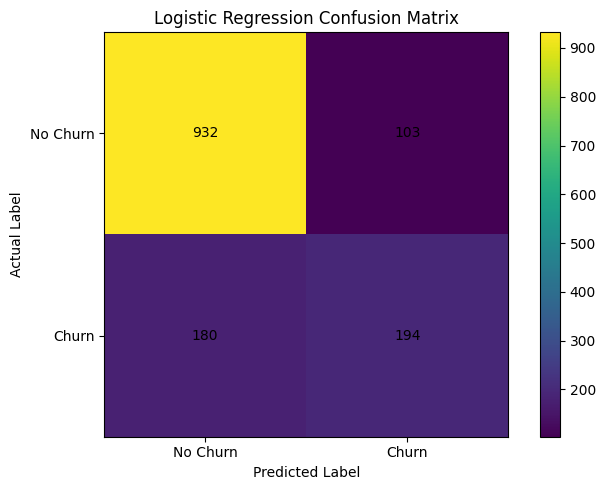

In [12]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(7, 5))

plt.imshow(cm_logistic)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_logistic[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [13]:
model_results = []

model_results.append({
    "Model": "Logistic Regression",
    "Accuracy": logistic_accuracy,
    "Precision": logistic_precision,
    "Recall": logistic_recall,
    "F1 Score": logistic_f1,
    "ROC-AUC": logistic_roc_auc
})

results_df = pd.DataFrame(model_results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.799148,0.653199,0.518717,0.578241,0.842419


## 6. Decision Tree

A Decision Tree classifier is developed as the second model.

Decision Trees make predictions by recursively splitting the dataset based on feature values. They are useful because their decision-making process can be relatively easy to interpret from a business perspective.

The model will be evaluated using the same metrics as Logistic Regression so that the algorithms can be compared objectively.

In [14]:
# Initialize Decision Tree

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train the model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [15]:
# Generate predictions

y_pred_tree = decision_tree_model.predict(X_test)

# Generate probability predictions
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree predictions generated successfully.")

Decision Tree predictions generated successfully.


In [16]:
# Decision Tree evaluation metrics

tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)
tree_roc_auc = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree Performance")
print("=" * 40)
print(f"Accuracy:  {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall:    {tree_recall:.4f}")
print(f"F1 Score:  {tree_f1:.4f}")
print(f"ROC-AUC:   {tree_roc_auc:.4f}")

Decision Tree Performance
Accuracy:  0.7984
Precision: 0.6347
Recall:    0.5668
F1 Score:  0.5989
ROC-AUC:   0.8298


In [17]:
print("Decision Tree Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=["No Churn", "Churn"]
    )
)

Decision Tree Classification Report
              precision    recall  f1-score   support

    No Churn       0.85      0.88      0.87      1035
       Churn       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



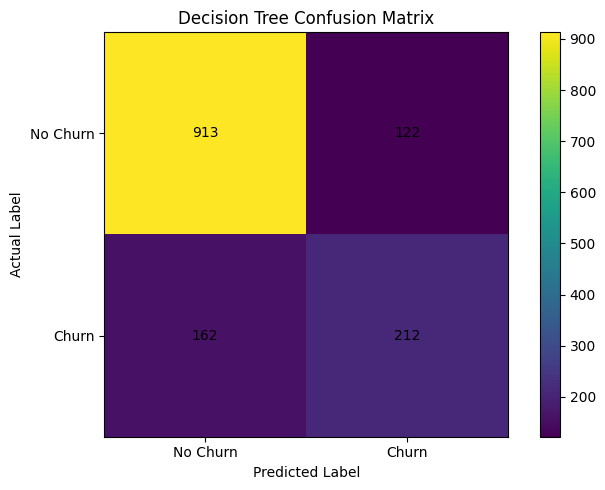

In [18]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(7, 5))

plt.imshow(cm_tree)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_tree[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [19]:
model_results.append({
    "Model": "Decision Tree",
    "Accuracy": tree_accuracy,
    "Precision": tree_precision,
    "Recall": tree_recall,
    "F1 Score": tree_f1,
    "ROC-AUC": tree_roc_auc
})

results_df = pd.DataFrame(model_results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.799148,0.653199,0.518717,0.578241,0.842419
1,Decision Tree,0.798439,0.634731,0.566845,0.598870,0.829844


## 7. Random Forest

Random Forest is an ensemble classification algorithm that combines multiple decision trees to produce a more robust prediction.

Unlike a single Decision Tree, Random Forest reduces the risk of overfitting by aggregating predictions from many trees.

The model will be evaluated using the same performance metrics used for the previous models.

In [20]:
# Initialize Random Forest

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [21]:
# Generate predictions

y_pred_rf = random_forest_model.predict(X_test)

# Generate probability predictions for ROC-AUC
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


In [22]:
# Random Forest evaluation metrics

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("=" * 40)
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")

Random Forest Performance
Accuracy:  0.7771
Precision: 0.6027
Recall:    0.4706
F1 Score:  0.5285
ROC-AUC:   0.8200


In [23]:
print("Random Forest Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["No Churn", "Churn"]
    )
)

Random Forest Classification Report
              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.85      1035
       Churn       0.60      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.78      0.77      1409



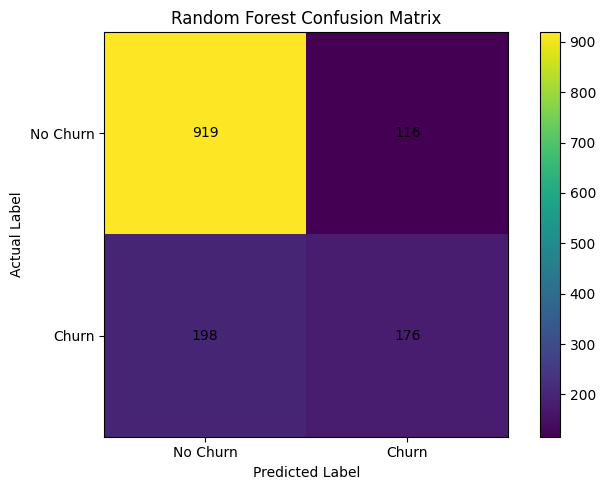

In [24]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))

plt.imshow(cm_rf)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_rf[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [25]:
model_results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1,
    "ROC-AUC": rf_roc_auc
})

results_df = pd.DataFrame(model_results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.799148,0.653199,0.518717,0.578241,0.842419
1,Decision Tree,0.798439,0.634731,0.566845,0.598870,0.829844
2,Random Forest,0.777147,0.602740,0.470588,0.528529,0.819997


In [26]:
!pip install xgboost -q

In [27]:
from xgboost import XGBClassifier

## 8. XGBoost

XGBoost (Extreme Gradient Boosting) is an ensemble machine learning algorithm that builds decision trees sequentially, with each new tree attempting to improve the errors made by previous trees.

It is included as the fourth classification model because gradient-boosting methods are widely used for structured/tabular datasets and can capture complex relationships between customer characteristics and churn.

The model will be evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.

In [28]:
# Initialize XGBoost

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [29]:
# Generate predictions

y_pred_xgb = xgb_model.predict(X_test)

# Generate probability predictions
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost predictions generated successfully.")

XGBoost predictions generated successfully.


In [30]:
# XGBoost evaluation metrics

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Performance")
print("=" * 40)
print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1 Score:  {xgb_f1:.4f}")
print(f"ROC-AUC:   {xgb_roc_auc:.4f}")

XGBoost Performance
Accuracy:  0.8027
Precision: 0.6611
Recall:    0.5267
F1 Score:  0.5863
ROC-AUC:   0.8446


In [31]:
print("XGBoost Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["No Churn", "Churn"]
    )
)

XGBoost Classification Report
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



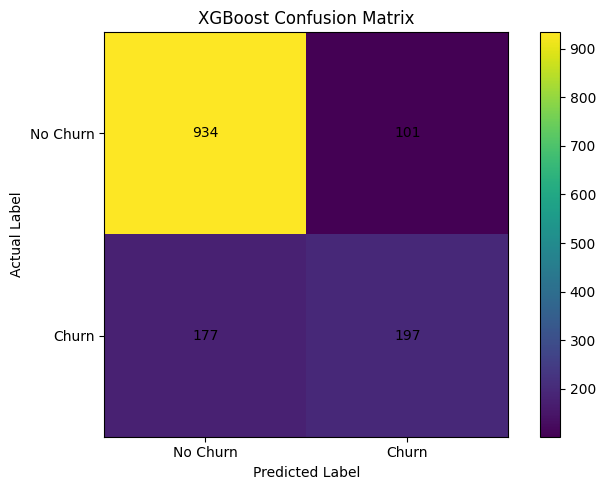

In [32]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(7, 5))

plt.imshow(cm_xgb)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_xgb[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [33]:
model_results.append({
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1 Score": xgb_f1,
    "ROC-AUC": xgb_roc_auc
})

results_df = pd.DataFrame(model_results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.799148,0.653199,0.518717,0.578241,0.842419
1,Decision Tree,0.798439,0.634731,0.566845,0.598870,0.829844
2,Random Forest,0.777147,0.602740,0.470588,0.528529,0.819997
3,XGBoost,0.802697,0.661074,0.526738,0.586310,0.844630


## 10. Model Performance Comparison

The performance of the four classification models is compared across accuracy, precision, recall, F1-score, and ROC-AUC.

This comparison helps identify the strengths and weaknesses of each algorithm and supports the final model selection.

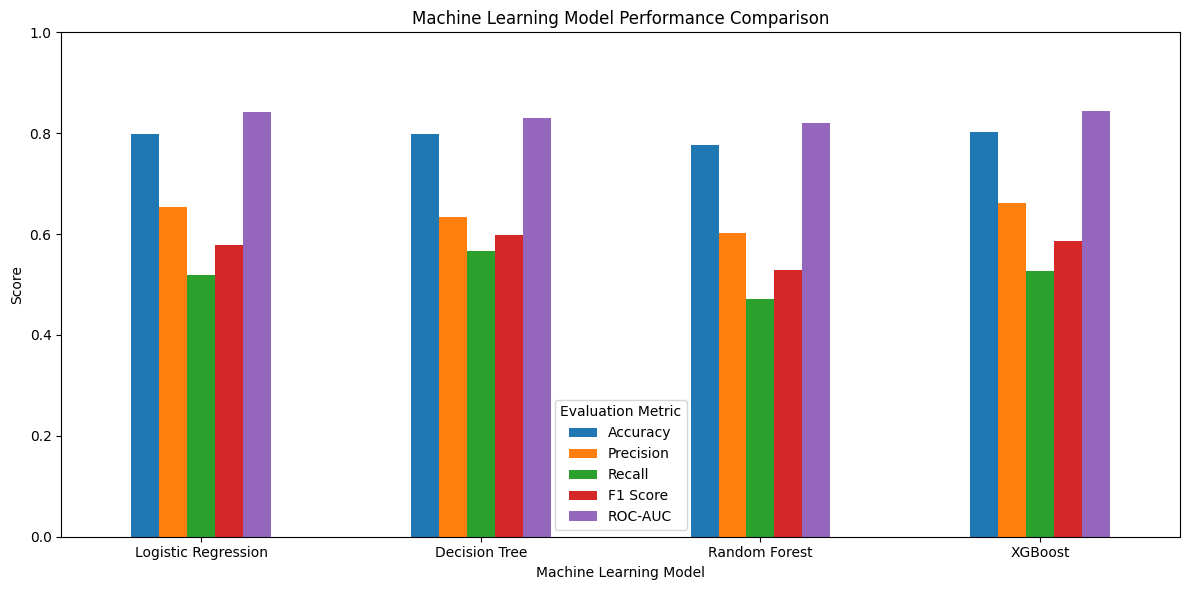

In [34]:
# Model performance comparison

comparison_plot = results_df.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Evaluation Metric")
plt.tight_layout()

plt.show()

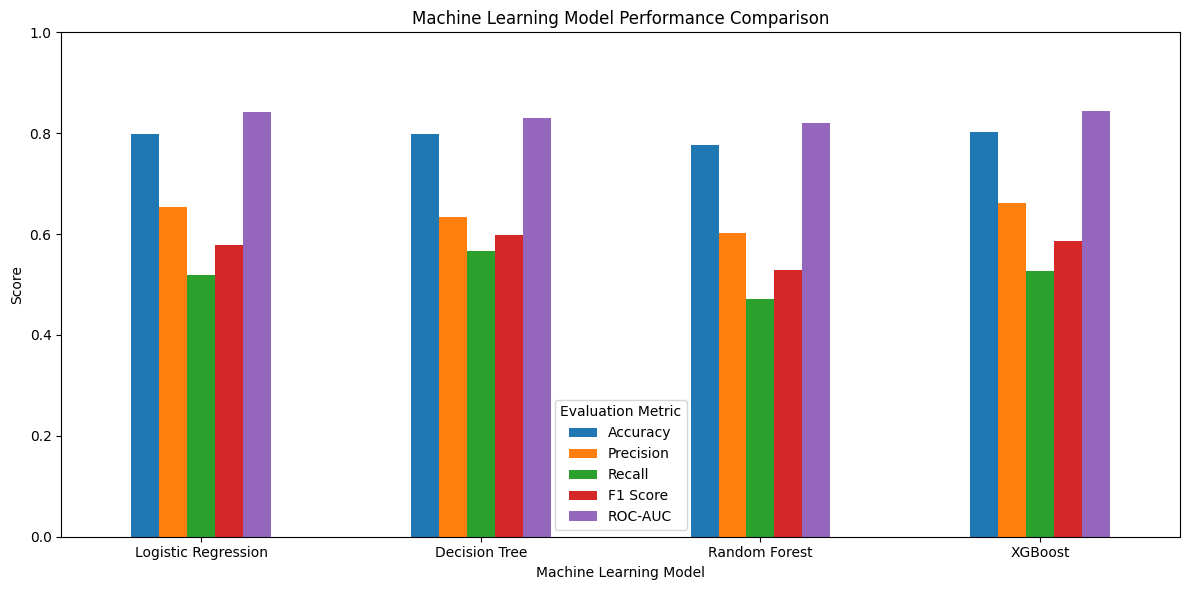

In [35]:
import os

os.makedirs("images/model_comparison", exist_ok=True)

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Evaluation Metric")
plt.tight_layout()

plt.savefig(
    "images/model_comparison/model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
# Generate Logistic Regression predictions

y_pred_logistic = logistic_model.predict(X_test)

# Generate probability predictions for ROC-AUC
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression predictions generated successfully.")

Logistic Regression predictions generated successfully.


In [39]:
models_predictions = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

In [40]:
for model_name, predictions in models_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    print(f"\n{model_name}")
    print("-" * 40)
    print(cm)


Logistic Regression
----------------------------------------
[[932 103]
 [180 194]]

Decision Tree
----------------------------------------
[[913 122]
 [162 212]]

Random Forest
----------------------------------------
[[919 116]
 [198 176]]

XGBoost
----------------------------------------
[[934 101]
 [177 197]]


In [41]:
model_probabilities = {
    "Logistic Regression": y_prob_logistic,
    "Decision Tree": y_prob_tree,
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb
}

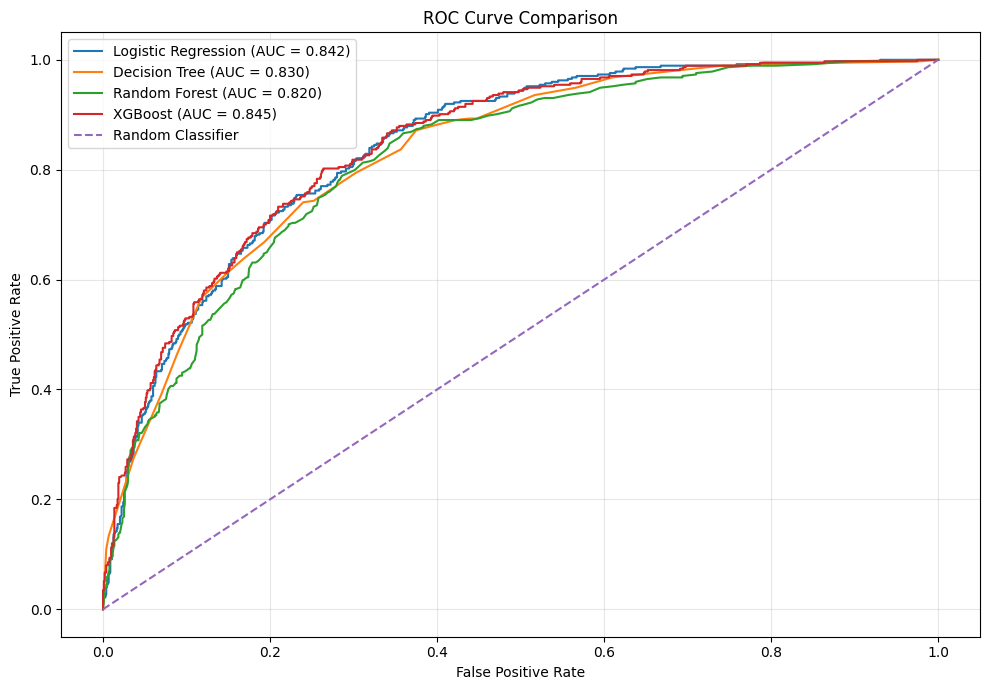

In [42]:
plt.figure(figsize=(10, 7))

for model_name, probabilities in model_probabilities.items():

    fpr, tpr, _ = roc_curve(y_test, probabilities)

    auc_score = roc_auc_score(y_test, probabilities)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
feature_names = X_train.columns.tolist()

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 50
['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges', 'num__TotalCharges', 'num__total_services', 'cat__gender_Female', 'cat__gender_Male', 'cat__Partner_No', 'cat__Partner_Yes', 'cat__Dependents_No', 'cat__Dependents_Yes', 'cat__PhoneService_No', 'cat__PhoneService_Yes', 'cat__MultipleLines_No', 'cat__MultipleLines_No phone service', 'cat__MultipleLines_Yes', 'cat__InternetService_DSL', 'cat__InternetService_Fiber optic', 'cat__InternetService_No', 'cat__OnlineSecurity_No', 'cat__OnlineSecurity_No internet service', 'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No', 'cat__OnlineBackup_No internet service', 'cat__OnlineBackup_Yes', 'cat__DeviceProtection_No', 'cat__DeviceProtection_No internet service', 'cat__DeviceProtection_Yes', 'cat__TechSupport_No', 'cat__TechSupport_No internet service', 'cat__TechSupport_Yes', 'cat__StreamingTV_No', 'cat__StreamingTV_No internet service', 'cat__StreamingTV_Yes', 'cat__StreamingMovies_No', 'cat__StreamingMovies_No in

In [44]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
37,cat__Contract_Month-to-month,0.334742
49,cat__tenure_group_New,0.070030
17,cat__InternetService_Fiber optic,0.069545
19,cat__OnlineSecurity_No,0.065245
39,cat__Contract_Two year,0.045047
28,cat__TechSupport_No,0.039910
16,cat__InternetService_DSL,0.031238
38,cat__Contract_One year,0.024062
44,cat__PaymentMethod_Electronic check,0.019540
36,cat__StreamingMovies_Yes,0.019450


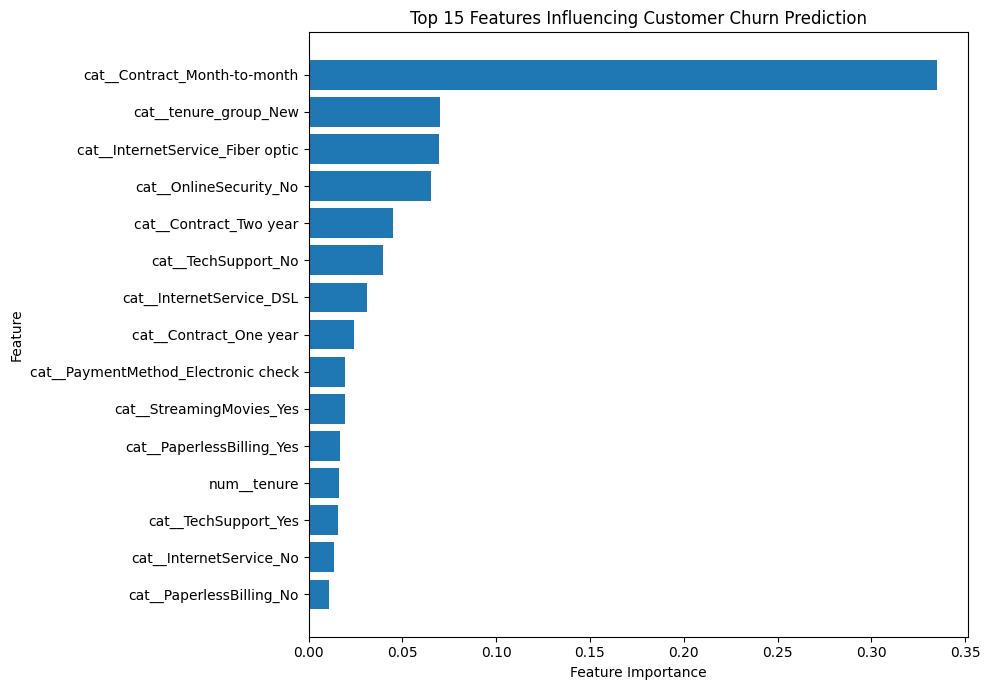

In [45]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features Influencing Customer Churn Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

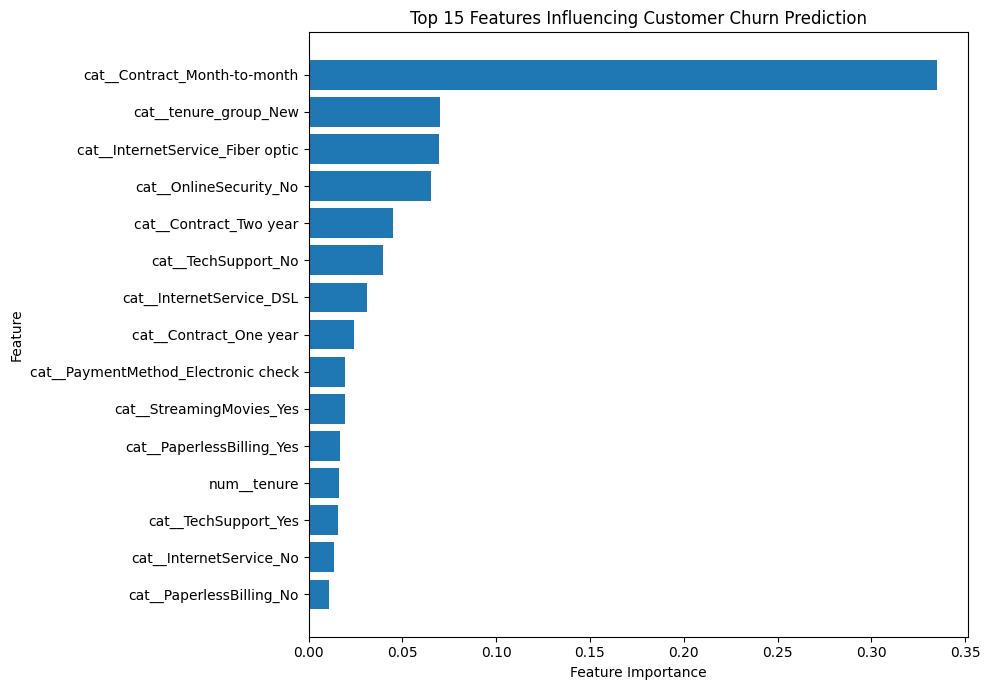

In [46]:
import os

os.makedirs("images/feature_importance", exist_ok=True)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features Influencing Customer Churn Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "images/feature_importance/top_15_churn_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
feature_importance.head(20)

,Feature,Importance
37,cat__Contract_Month-to-month,0.334742
49,cat__tenure_group_New,0.070030
17,cat__InternetService_Fiber optic,0.069545
19,cat__OnlineSecurity_No,0.065245
39,cat__Contract_Two year,0.045047
28,cat__TechSupport_No,0.039910
16,cat__InternetService_DSL,0.031238
38,cat__Contract_One year,0.024062
44,cat__PaymentMethod_Electronic check,0.019540
36,cat__StreamingMovies_Yes,0.019450


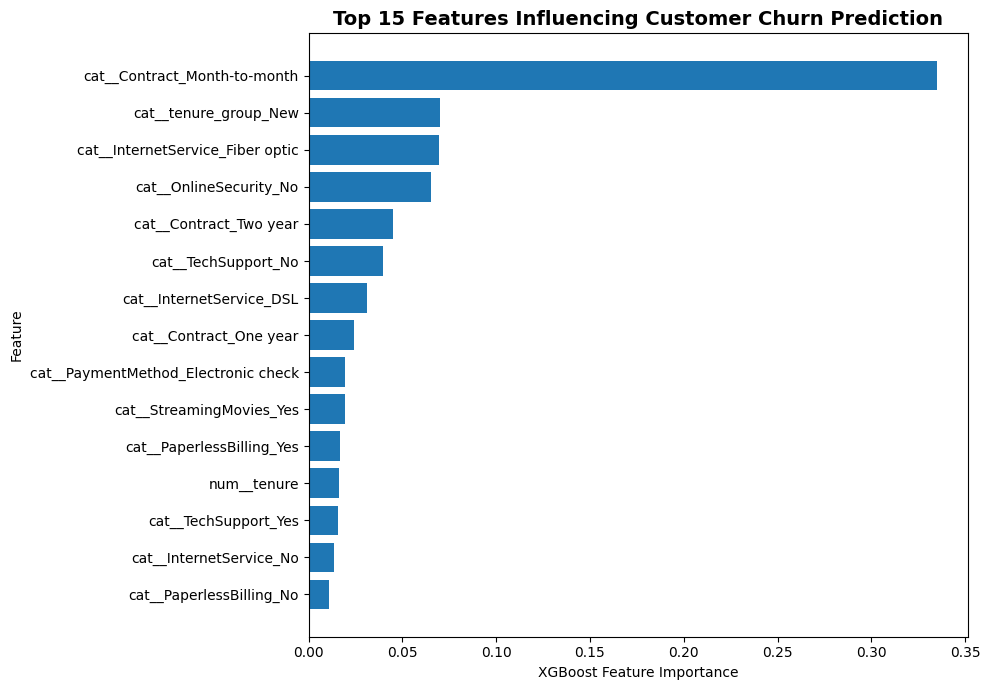

In [48]:
# Top 15 XGBoost features

top_features = (
    feature_importance
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 15 Features Influencing Customer Churn Prediction",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

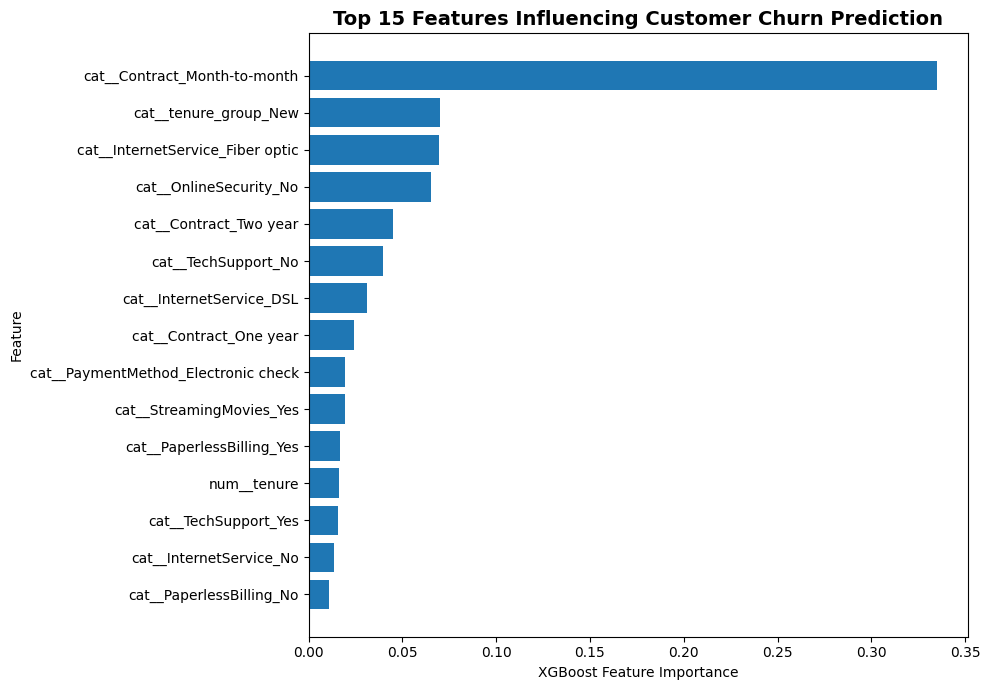

In [49]:
import os

os.makedirs("images/feature_importance", exist_ok=True)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 15 Features Influencing Customer Churn Prediction",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "images/feature_importance/top_15_churn_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11. Precision–Recall Curve Comparison

The Precision–Recall curve evaluates the trade-off between precision and recall across different classification thresholds.

This is particularly useful for the customer churn problem because the dataset contains more non-churn customers than churn customers.

A model with higher precision identifies likely churners more accurately, while higher recall means the model is able to identify a larger proportion of customers who actually churn.

The curves below are compared across all four machine learning models.

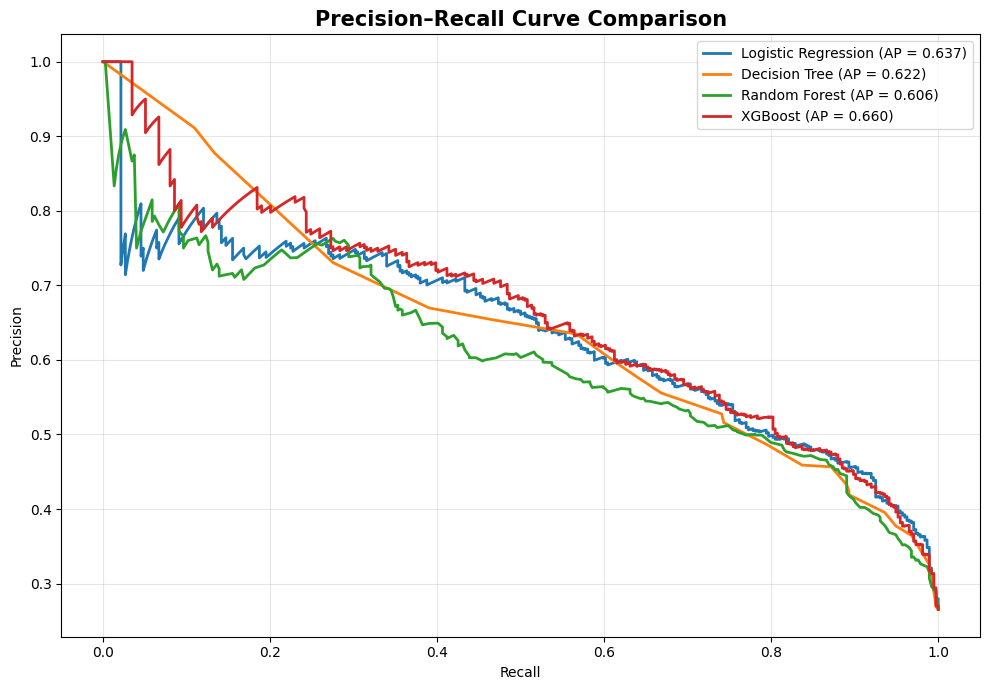

In [51]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for model_name, probabilities in model_probabilities.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities
    )

    ap_score = average_precision_score(
        y_test,
        probabilities
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{model_name} (AP = {ap_score:.3f})"
    )

plt.title(
    "Precision–Recall Curve Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

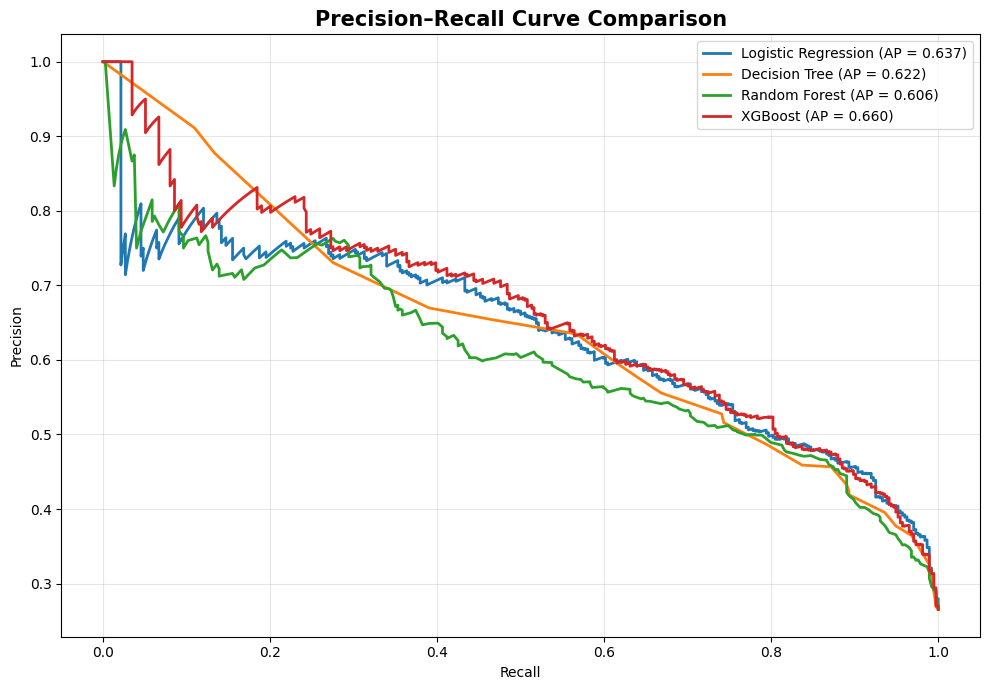

In [52]:
import os

os.makedirs("images/other_visualizations", exist_ok=True)

plt.figure(figsize=(10, 7))

for model_name, probabilities in model_probabilities.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities
    )

    ap_score = average_precision_score(
        y_test,
        probabilities
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{model_name} (AP = {ap_score:.3f})"
    )

plt.title(
    "Precision–Recall Curve Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "images/other_visualizations/precision_recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The Precision–Recall curves provide additional insight into the ability of each model to identify customers who are likely to churn.

The curves demonstrate the trade-off between identifying more actual churners (recall) and maintaining accurate churn predictions (precision).

XGBoost demonstrates strong overall predictive performance and is particularly competitive across the precision–recall trade-off. However, the Decision Tree achieves a higher recall at the default classification threshold.

From a business perspective, the choice of threshold could therefore be adjusted depending on whether the company prioritizes identifying as many potential churners as possible or reducing the number of customers incorrectly targeted for retention campaigns.

In [53]:
# Prepare model comparison data

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

comparison_df = results_df.copy()

comparison_df = comparison_df.set_index("Model")[metrics]

comparison_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.799148,0.653199,0.518717,0.578241,0.842419
Decision Tree,0.798439,0.634731,0.566845,0.598870,0.829844
Random Forest,0.777147,0.602740,0.470588,0.528529,0.819997
XGBoost,0.802697,0.661074,0.526738,0.586310,0.844630


<Figure size 1200x700 with 0 Axes>

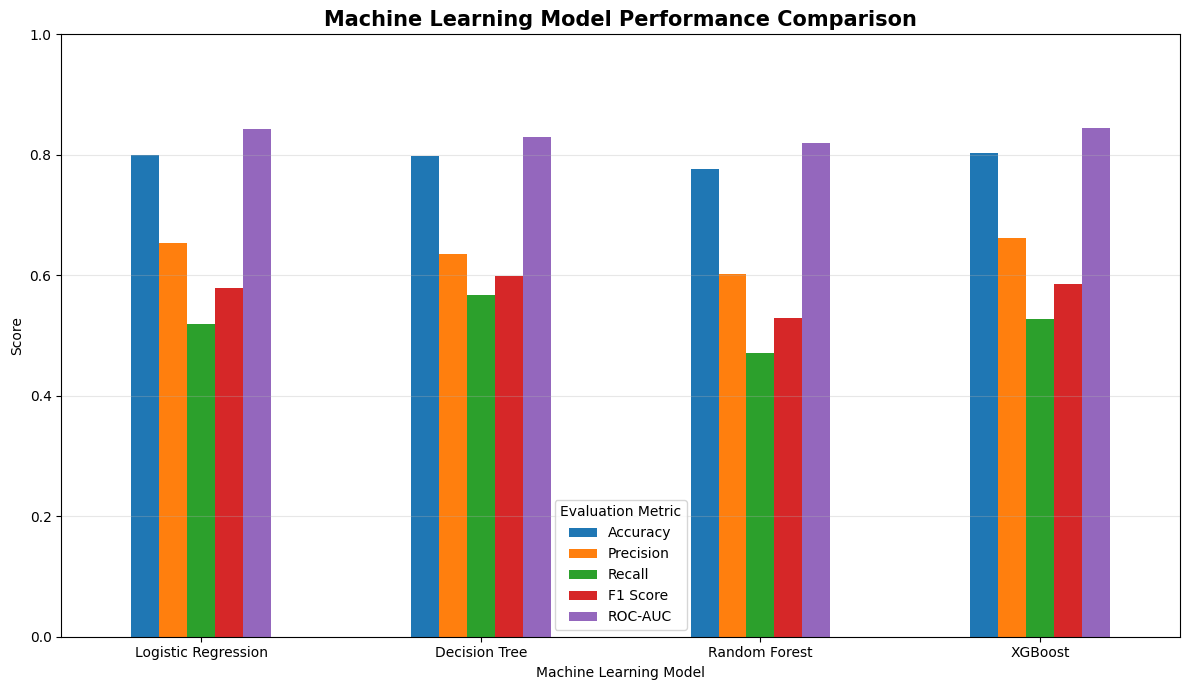

In [54]:
plt.figure(figsize=(12, 7))

comparison_df.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title(
    "Machine Learning Model Performance Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Evaluation Metric")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

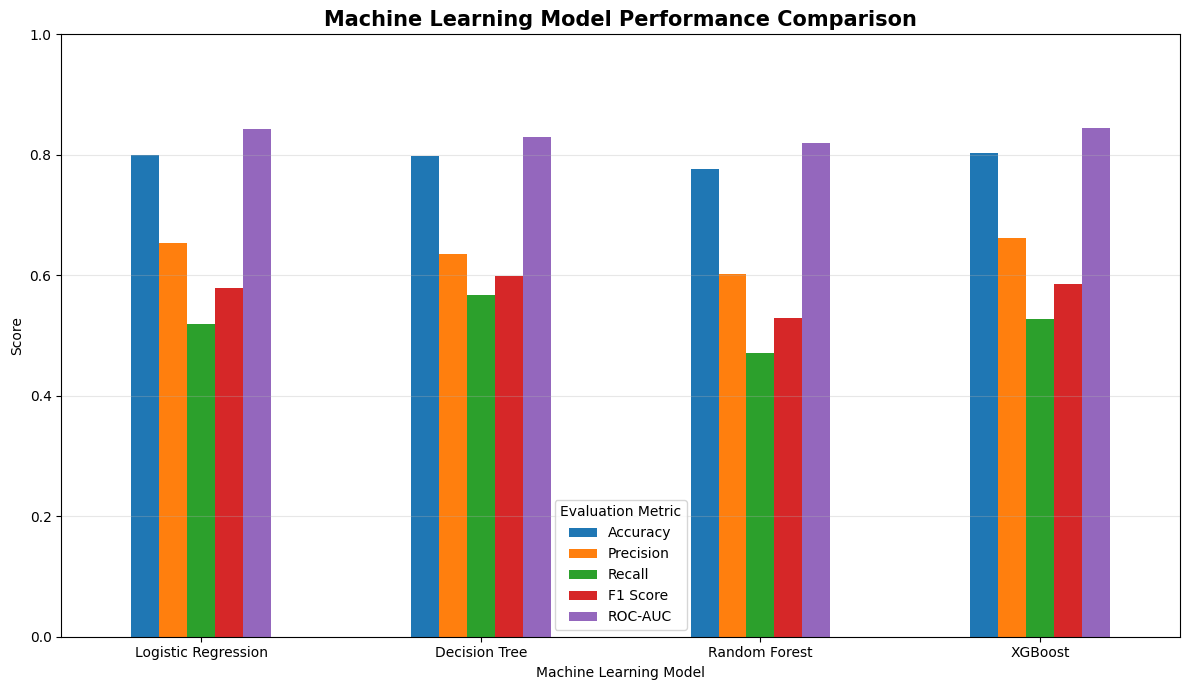

In [55]:
import os

os.makedirs("images/model_comparison", exist_ok=True)

comparison_df.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title(
    "Machine Learning Model Performance Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Evaluation Metric")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "images/model_comparison/model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 12. Learning Curve Analysis

Learning curves show how model performance changes as the amount of training data increases.

They help identify potential overfitting and underfitting:

- If training and validation scores are both low, the model may be underfitting.
- If training performance is much higher than validation performance, the model may be overfitting.
- If the two scores converge at a high performance level, the model is likely generalizing well.

Learning curves are examined for the four classification models developed in this project.

In [57]:
import pandas as pd

train_path = "/kaggle/input/datasets/christianagyapong1/dataset/X_train_processed.csv"
test_path = "/kaggle/input/datasets/christianagyapong1/dataset/X_test_processed.csv"

X_train_processed = pd.read_csv(train_path)
X_test_processed = pd.read_csv(test_path)

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (5634, 51)
Testing shape: (1409, 51)


In [58]:
y_train = X_train_processed["Churn"]
y_test = X_test_processed["Churn"]

X_train_processed = X_train_processed.drop(columns=["Churn"])
X_test_processed = X_test_processed.drop(columns=["Churn"])

print("X_train_processed:", X_train_processed.shape)
print("X_test_processed:", X_test_processed.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train_processed: (5634, 50)
X_test_processed: (1409, 50)
y_train: (5634,)
y_test: (1409,)


In [59]:
print("Training data:")
print(X_train_processed.shape)

print("\nTesting data:")
print(X_test_processed.shape)

print("\nData types:")
print(X_train_processed.dtypes.value_counts())

print("\nMissing values:")
print(X_train_processed.isnull().sum().sum())


Training data:
(5634, 50)

Testing data:
(1409, 50)

Data types:
float64    50
Name: count, dtype: int64

Missing values:
0


In [60]:
models_for_learning = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model
}

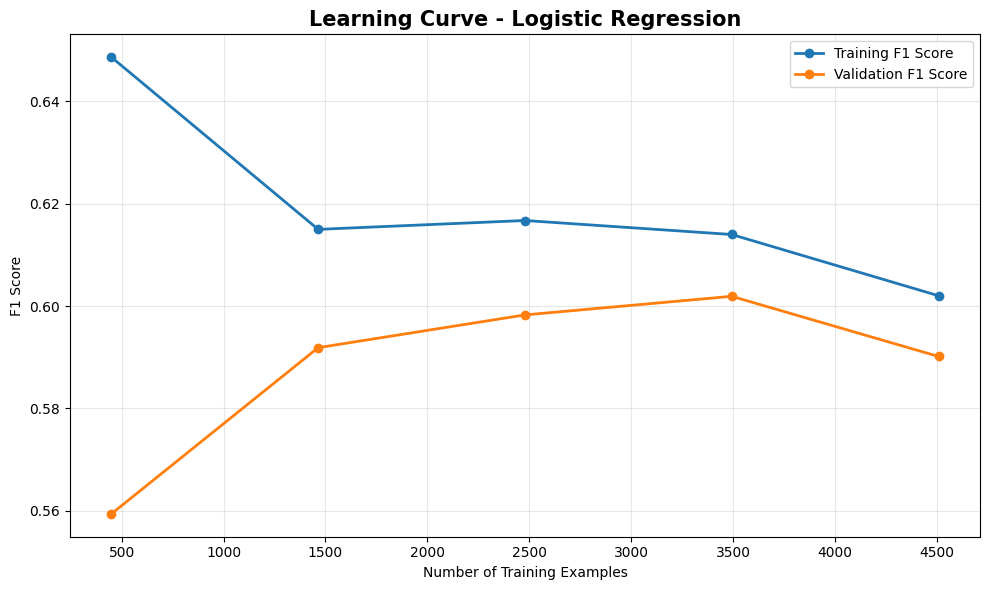

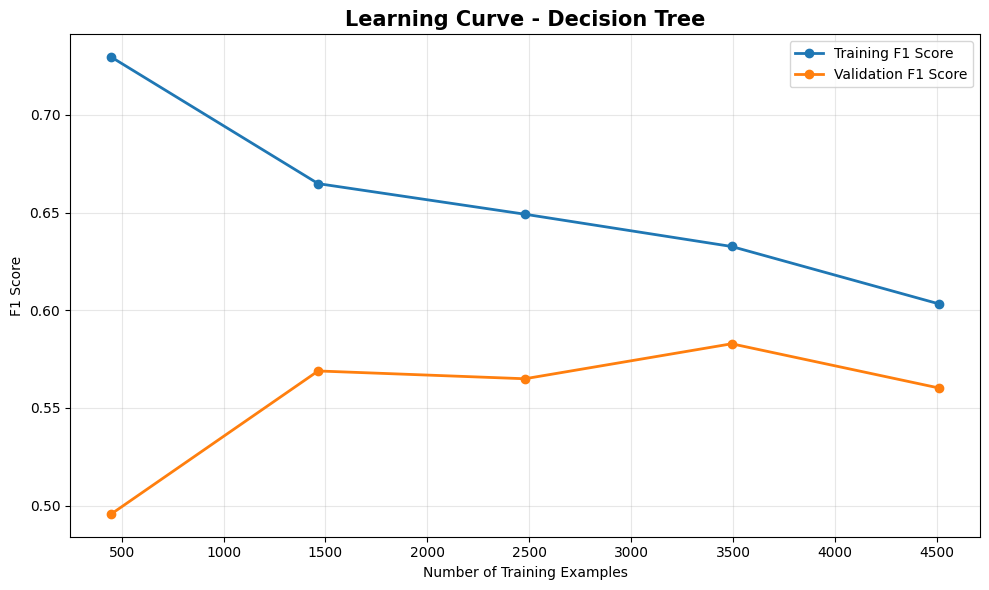

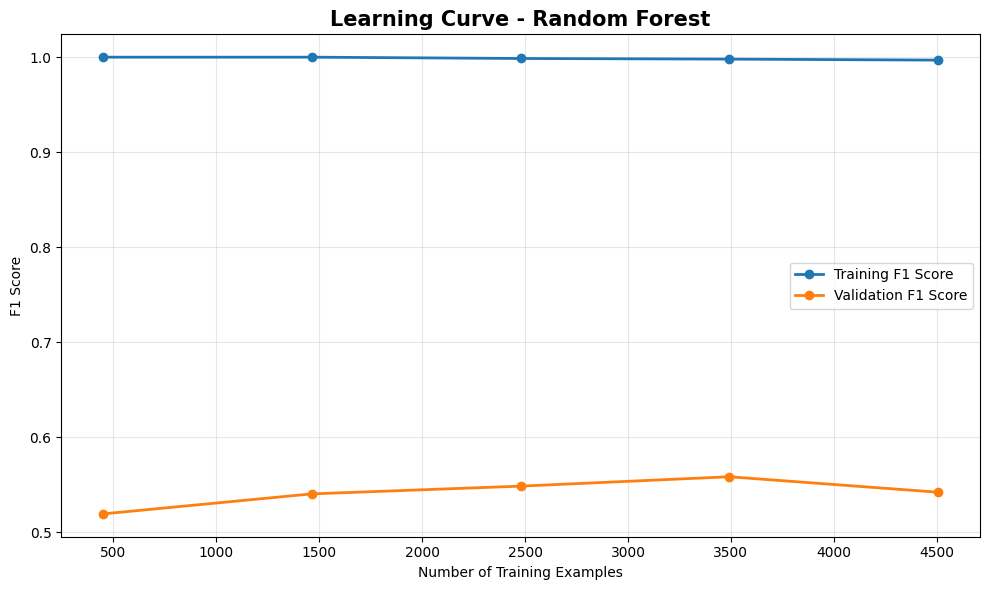

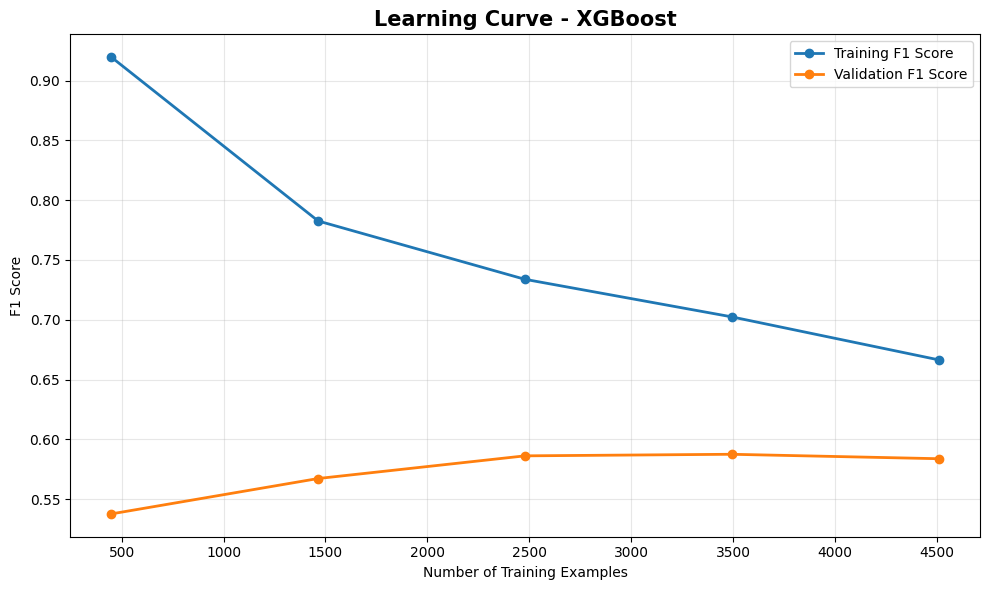

In [61]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt
import os

# Create output directory
os.makedirs("images/learning_curves", exist_ok=True)

for model_name, model in models_for_learning.items():

    train_sizes, train_scores, validation_scores = learning_curve(
        model,
        X_train_processed,
        y_train,
        cv=5,
        scoring="f1",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    validation_mean = validation_scores.mean(axis=1)

    plt.figure(figsize=(10, 6))

    plt.plot(
        train_sizes,
        train_mean,
        marker="o",
        linewidth=2,
        label="Training F1 Score"
    )

    plt.plot(
        train_sizes,
        validation_mean,
        marker="o",
        linewidth=2,
        label="Validation F1 Score"
    )

    plt.title(
        f"Learning Curve - {model_name}",
        fontsize=15,
        fontweight="bold"
    )

    plt.xlabel("Number of Training Examples")
    plt.ylabel("F1 Score")

    plt.legend()
    plt.grid(alpha=0.3)

    filename = (
        model_name.lower()
        .replace(" ", "_")
        .replace("-", "")
    )

    plt.tight_layout()

    plt.savefig(
        f"images/learning_curves/{filename}_learning_curve.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## Learning Curve Interpretation

Learning curves were used to assess how model performance changes as the amount of training data increases.

The training and validation F1 scores were compared to identify potential underfitting or overfitting.

A large difference between training and validation performance may indicate overfitting, while consistently low performance on both curves may indicate underfitting.

The learning curve analysis provides additional evidence about the generalization ability of the models and complements the evaluation performed using the test dataset.

## 13. Feature Importance Analysis

Feature importance analysis identifies the variables that contribute most to the model's predictions.

For this project, XGBoost feature importance is used to determine which customer characteristics are most influential in predicting customer churn.

Understanding these predictors is important not only from a technical perspective but also from a business perspective because it helps the organization identify factors associated with customer attrition.

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Get feature importance from XGBoost
feature_importance = xgb_model.feature_importances_

# Get feature names
feature_names = X_train_processed.columns

# Create feature importance DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top 20
importance_df.head(20)

,Feature,Importance
37,cat__Contract_Month-to-month,0.334742
49,cat__tenure_group_New,0.070030
17,cat__InternetService_Fiber optic,0.069545
19,cat__OnlineSecurity_No,0.065245
39,cat__Contract_Two year,0.045047
28,cat__TechSupport_No,0.039910
16,cat__InternetService_DSL,0.031238
38,cat__Contract_One year,0.024062
44,cat__PaymentMethod_Electronic check,0.019540
36,cat__StreamingMovies_Yes,0.019450


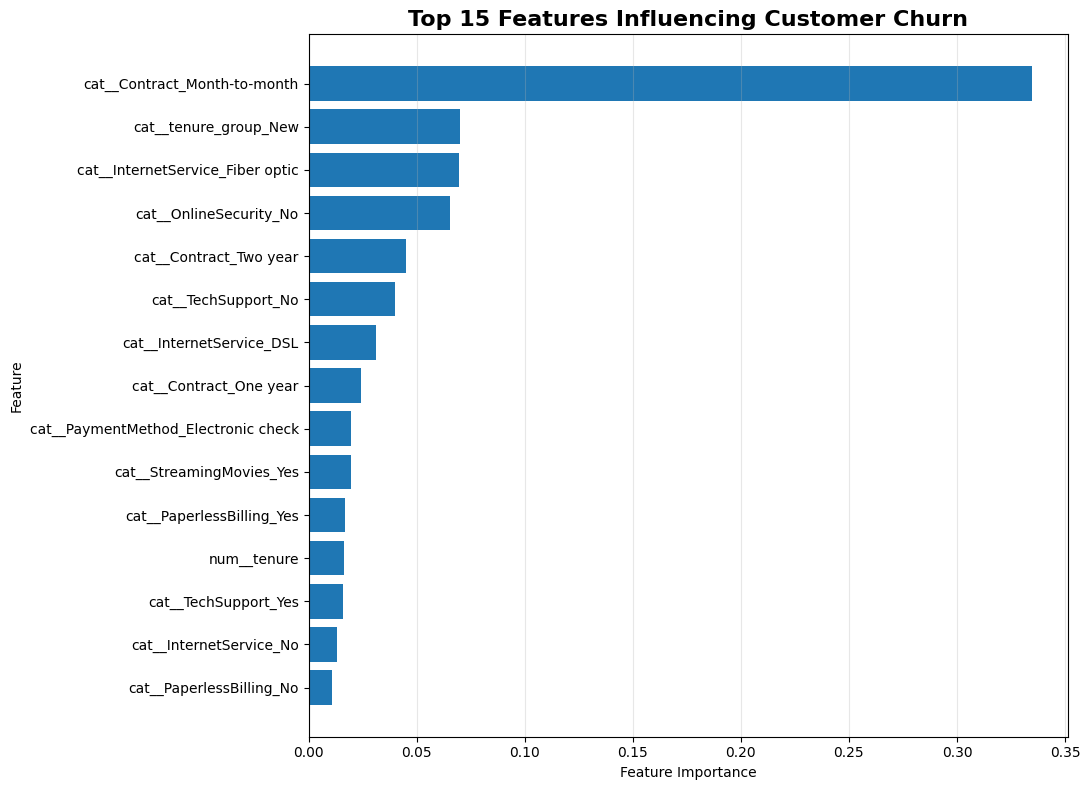

In [64]:
# Select top 15 features
top_features = importance_df.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(11, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 15 Features Influencing Customer Churn",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.show()

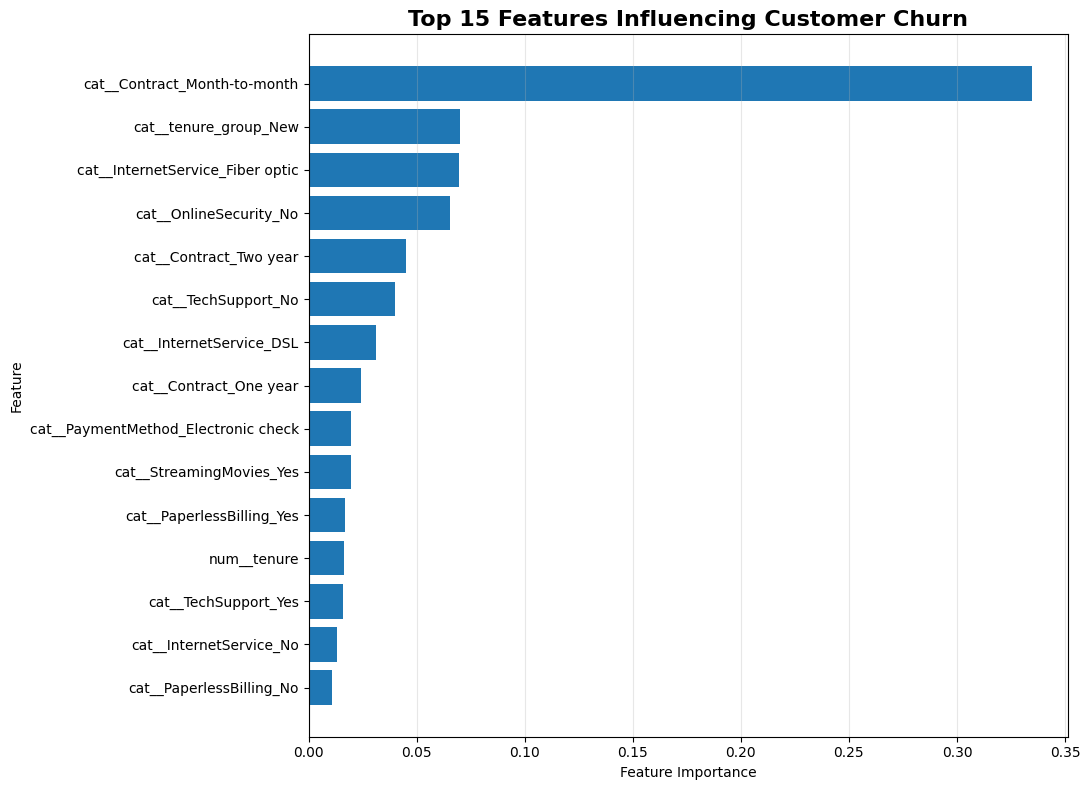

In [65]:
os.makedirs("images/feature_importance", exist_ok=True)

plt.figure(figsize=(11, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 15 Features Influencing Customer Churn",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "images/feature_importance/top_15_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Interpretation

The feature importance analysis shows that contract type is one of the strongest predictors of customer churn.

In particular, customers on month-to-month contracts have substantially higher predictive importance than customers on longer-term contracts.

Other influential features include:

- New customer tenure group.
- Fiber optic internet service.
- Online security subscription.
- Technical support subscription.
- Payment method.
- Streaming services.
- Paperless billing.

These findings suggest that customer retention strategies should pay particular attention to customers with short tenure and month-to-month contracts.

The organization could consider targeted retention campaigns, improved onboarding experiences, loyalty incentives, and longer-term contract benefits for customers who demonstrate a high risk of churn.

In [66]:
importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance file saved successfully.")

Feature importance file saved successfully.


## 14. Final Model Recommendation

Based on the evaluation results, XGBoost is recommended as the best overall model for customer churn prediction.

XGBoost achieved the highest:

- Accuracy: 80.27%
- Precision: 66.11%
- ROC-AUC: 84.46%

Although the Decision Tree achieved a slightly higher recall and F1 score, XGBoost provides the strongest overall balance across the evaluation metrics and achieved the highest ROC-AUC.

The model is therefore recommended as the primary candidate for deployment, subject to further validation and business testing.

From a business perspective, the model can be used to identify customers who are more likely to churn and support targeted customer retention strategies.

However, the model should not be deployed as the sole decision-making mechanism. Its predictions should be combined with business rules, customer context, monitoring, and periodic model evaluation.

## 15. Confusion Matrix Comparison

Confusion matrices provide a detailed view of the classification results for each machine learning model.

For the customer churn problem:

- True Negative (TN): Customer correctly predicted not to churn.
- False Positive (FP): Customer incorrectly predicted to churn.
- False Negative (FN): Customer who churns but was predicted not to churn.
- True Positive (TP): Customer correctly predicted to churn.

False negatives are particularly important from a business perspective because they represent customers who are likely to leave but were not identified by the model.

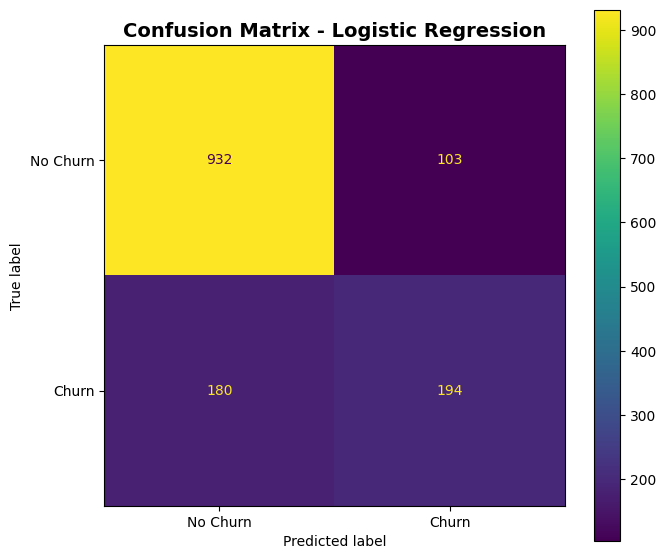

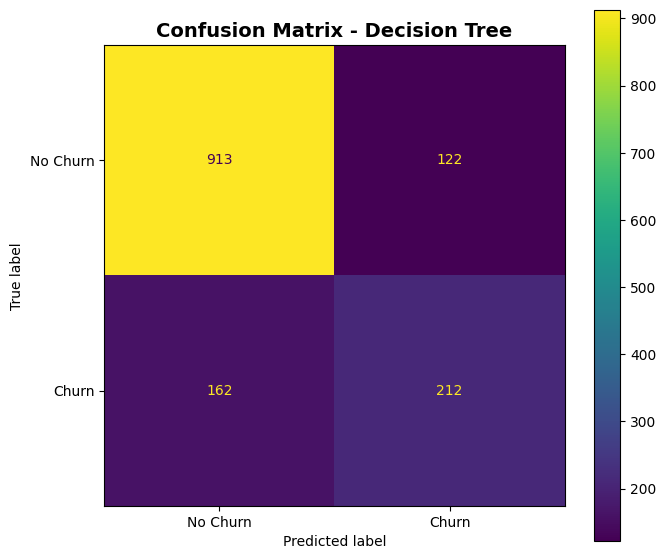

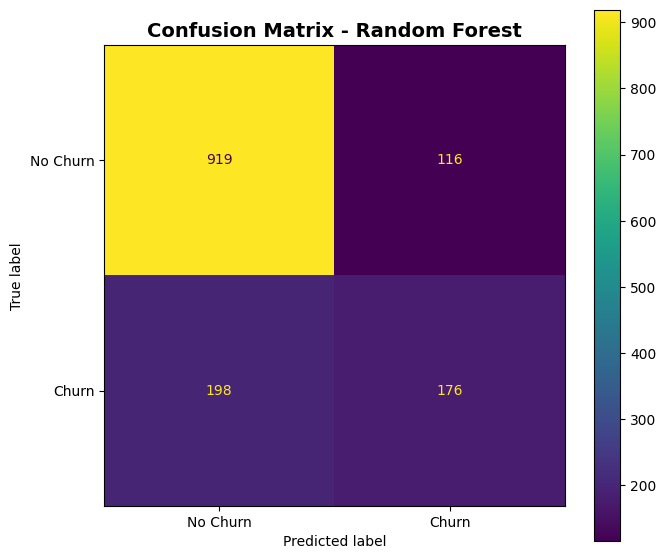

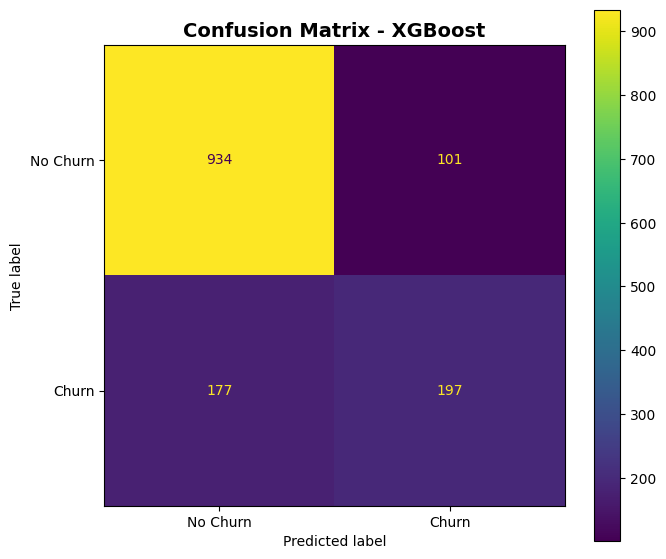

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

os.makedirs("images/confusion_matrices", exist_ok=True)

for model_name, predictions in models_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    fig, ax = plt.subplots(figsize=(7, 6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )

    disp.plot(
        ax=ax,
        values_format="d"
    )

    ax.set_title(
        f"Confusion Matrix - {model_name}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()

    filename = (
        model_name.lower()
        .replace(" ", "_")
        .replace("-", "")
    )

    plt.savefig(
        f"images/confusion_matrices/{filename}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    

### Confusion Matrix Interpretation

XGBoost correctly classified 934 customers who did not churn and 197 customers who churned.

It produced 101 false positives and 177 false negatives.

The Decision Tree identified the highest number of actual churners, with 212 true positives and 162 false negatives, resulting in the highest recall among the four models.

However, XGBoost produced the lowest number of false positives among the four models and achieved the strongest overall ROC-AUC and accuracy.

This demonstrates that model selection depends on the business objective. If the organization prioritizes identifying as many potential churners as possible, the Decision Tree's higher recall may be valuable. If the organization wants a stronger overall predictive model, XGBoost provides the better balance.

## 16. Final Model Comparison

The four classification models were compared using accuracy, precision, recall, F1 score, and ROC-AUC.

The comparison provides both technical and business evidence for selecting the most appropriate model for customer churn prediction.

In [68]:
final_comparison = results_df.copy()

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.799148,0.653199,0.518717,0.578241,0.842419
1,Decision Tree,0.798439,0.634731,0.566845,0.598870,0.829844
2,Random Forest,0.777147,0.602740,0.470588,0.528529,0.819997
3,XGBoost,0.802697,0.661074,0.526738,0.586310,0.844630


# 17. Final Conclusion

This project developed and evaluated four supervised machine learning models for predicting customer churn:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

The models were trained using the processed customer dataset and evaluated using accuracy, precision, recall, F1 score, ROC-AUC, and confusion matrices.

Among the models tested, XGBoost achieved the strongest overall performance, with an accuracy of 80.27% and ROC-AUC of 84.46%.

The feature importance analysis also revealed that contract type, customer tenure, internet service type, online security, technical support, and payment method are among the important predictors associated with churn prediction.

The results indicate that machine learning can provide useful predictive information for identifying customers who may be at risk of leaving.

However, the model should be treated as a decision-support tool rather than a replacement for business judgment. Before deployment, further validation should be performed using new customer data, threshold optimization, model monitoring, and periodic retraining.

The recommended next step is to integrate the selected model into a customer retention workflow where high-risk customers can be identified and targeted with appropriate retention strategies.